# Classification with an Academic Success

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/playground-series-s4e6/sample_submission.csv
/kaggle/input/competitions/playground-series-s4e6/train.csv
/kaggle/input/competitions/playground-series-s4e6/test.csv


In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# ML Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.naive_bayes import BernoulliNB
from sklearn.naive_bayes import MultinomialNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier


# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

In [3]:
train = pd.read_csv("/kaggle/input/competitions/playground-series-s4e6/train.csv")
test = pd.read_csv("/kaggle/input/competitions/playground-series-s4e6/test.csv")

In [4]:
print(train.shape)
print(test.shape)

(76518, 38)
(51012, 37)


In [5]:
train.head()

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,1,1,1,9238,1,1,126.0,1,1,...,0,6,7,6,12.428571,0,11.1,0.6,2.02,Graduate
1,1,1,17,1,9238,1,1,125.0,1,19,...,0,6,9,0,0.000000,0,11.1,0.6,2.02,Dropout
2,2,1,17,2,9254,1,1,137.0,1,3,...,0,6,0,0,0.000000,0,16.2,0.3,-0.92,Dropout
3,3,1,1,3,9500,1,1,131.0,1,19,...,0,8,11,7,12.820000,0,11.1,0.6,2.02,Enrolled
4,4,1,1,2,9500,1,1,132.0,1,19,...,0,7,12,6,12.933333,0,7.6,2.6,0.32,Graduate


In [6]:
train.isnull().sum()

id                                                0
Marital status                                    0
Application mode                                  0
Application order                                 0
Course                                            0
Daytime/evening attendance                        0
Previous qualification                            0
Previous qualification (grade)                    0
Nacionality                                       0
Mother's qualification                            0
Father's qualification                            0
Mother's occupation                               0
Father's occupation                               0
Admission grade                                   0
Displaced                                         0
Educational special needs                         0
Debtor                                            0
Tuition fees up to date                           0
Gender                                            0
Scholarship 

In [7]:
test.head()

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP
0,76518,1,1,1,9500,1,1,141.0,1,3,...,0,0,8,0,0,0.000000,0,13.9,-0.3,0.79
1,76519,1,1,1,9238,1,1,128.0,1,1,...,0,0,6,6,6,13.500000,0,11.1,0.6,2.02
2,76520,1,1,1,9238,1,1,118.0,1,1,...,0,0,6,11,5,11.000000,0,15.5,2.8,-4.06
3,76521,1,44,1,9147,1,39,130.0,1,1,...,0,3,8,14,5,11.000000,0,8.9,1.4,3.51
4,76522,1,39,1,9670,1,1,110.0,1,1,...,0,0,6,9,4,10.666667,2,7.6,2.6,0.32


In [8]:
df=pd.concat([train,test]) 

## EDA

In [9]:
df.head()

,id,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,0,1,1,1,9238,1,1,126.0,1,1,...,0,6,7,6,12.428571,0,11.1,0.6,2.02,Graduate
1,1,1,17,1,9238,1,1,125.0,1,19,...,0,6,9,0,0.000000,0,11.1,0.6,2.02,Dropout
2,2,1,17,2,9254,1,1,137.0,1,3,...,0,6,0,0,0.000000,0,16.2,0.3,-0.92,Dropout
3,3,1,1,3,9500,1,1,131.0,1,19,...,0,8,11,7,12.820000,0,11.1,0.6,2.02,Enrolled
4,4,1,1,2,9500,1,1,132.0,1,19,...,0,7,12,6,12.933333,0,7.6,2.6,0.32,Graduate


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 127530 entries, 0 to 51011
Data columns (total 38 columns):
 #   Column                                          Non-Null Count   Dtype  
---  ------                                          --------------   -----  
 0   id                                              127530 non-null  int64  
 1   Marital status                                  127530 non-null  int64  
 2   Application mode                                127530 non-null  int64  
 3   Application order                               127530 non-null  int64  
 4   Course                                          127530 non-null  int64  
 5   Daytime/evening attendance                      127530 non-null  int64  
 6   Previous qualification                          127530 non-null  int64  
 7   Previous qualification (grade)                  127530 non-null  float64
 8   Nacionality                                     127530 non-null  int64  
 9   Mother's qualification          

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,127530.0,63764.500000,36814.884252,0.00,31882.250000,63764.500000,95646.750000,127529.000
Marital status,127530.0,1.110797,0.440239,1.00,1.000000,1.000000,1.000000,6.000
Application mode,127530.0,16.059492,16.671022,1.00,1.000000,17.000000,39.000000,53.000
Application order,127530.0,1.645911,1.232054,0.00,1.000000,1.000000,2.000000,9.000
Course,127530.0,9011.293649,1782.812455,33.00,9119.000000,9254.000000,9670.000000,9991.000
Daytime/evening attendance,127530.0,0.916514,0.276617,0.00,1.000000,1.000000,1.000000,1.000
Previous qualification,127530.0,3.649259,8.605169,1.00,1.000000,1.000000,1.000000,43.000
Previous qualification (grade),127530.0,132.358460,10.951586,95.00,125.000000,133.100000,140.000000,190.000
Nacionality,127530.0,1.215996,3.341797,1.00,1.000000,1.000000,1.000000,109.000
Mother's qualification,127530.0,19.867890,15.393189,1.00,1.000000,19.000000,37.000000,44.000


In [12]:
df.shape

(127530, 38)

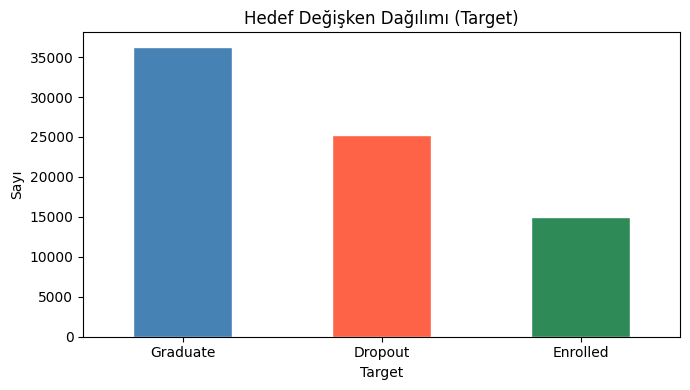

In [13]:
#Target distribution
plt.figure(figsize=(7, 4))
train['Target'].value_counts().plot(kind='bar', color=['steelblue','tomato','seagreen'], edgecolor='white')
plt.title('Hedef Değişken Dağılımı (Target)')
plt.xticks(rotation=0)
plt.ylabel('Sayı')
plt.tight_layout()
plt.show()

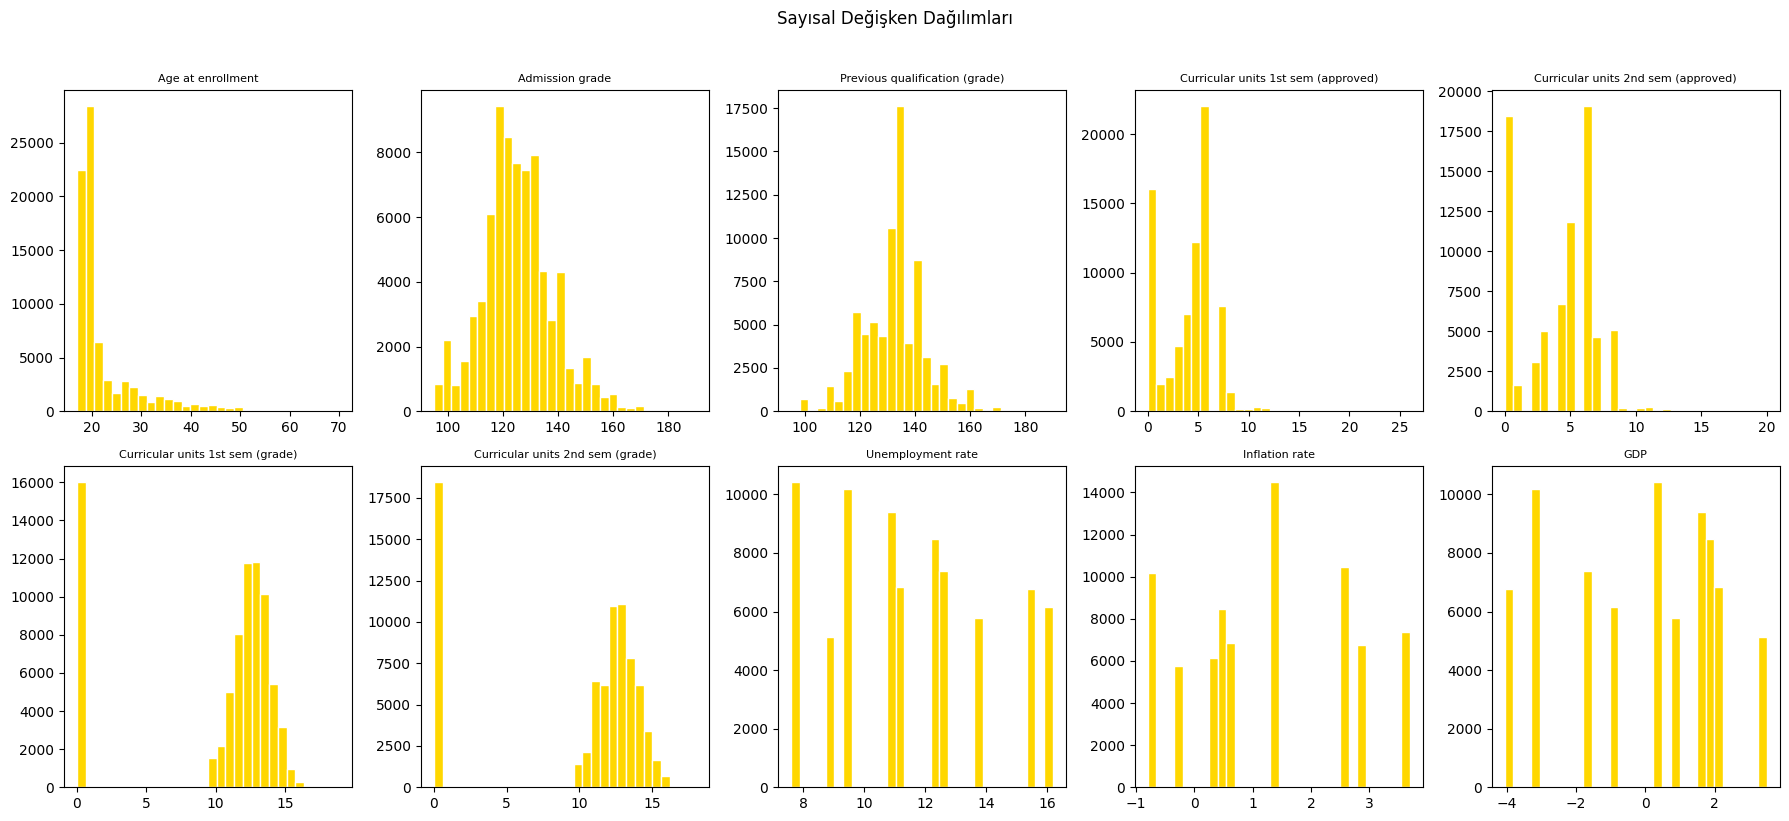

In [14]:
#Numeric cols
num_cols = ['Age at enrollment', 'Admission grade', 'Previous qualification (grade)',
            'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)',
            'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
            'Unemployment rate', 'Inflation rate', 'GDP']

plt.figure(figsize=(18, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 5, i)
    plt.hist(train[col], bins=30, color='Gold', edgecolor='white')
    plt.title(col, fontsize=8)
plt.suptitle('Sayısal Değişken Dağılımları', y=1.02)
plt.tight_layout()
plt.show()

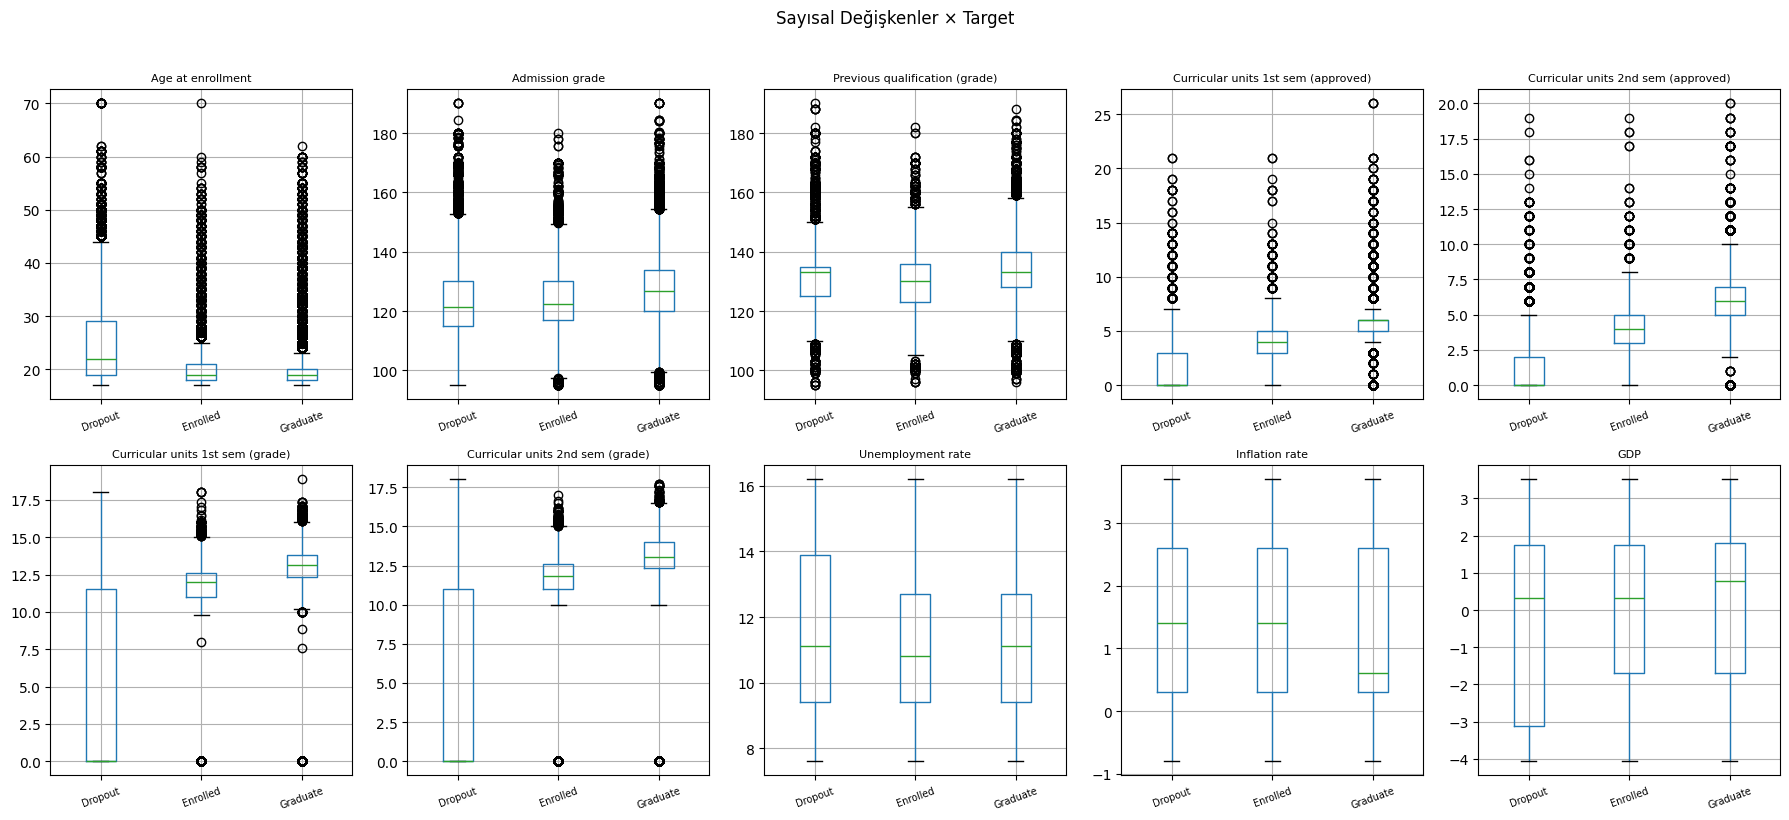

In [15]:
#BoxPlot
plt.figure(figsize=(18, 8))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 5, i)
    train.boxplot(column=col, by='Target', ax=plt.gca())
    plt.title(col, fontsize=8)
    plt.suptitle('')
    plt.xlabel('')
    plt.xticks(rotation=20, fontsize=7)
plt.suptitle('Sayısal Değişkenler × Target', y=1.02)
plt.tight_layout()
plt.show()

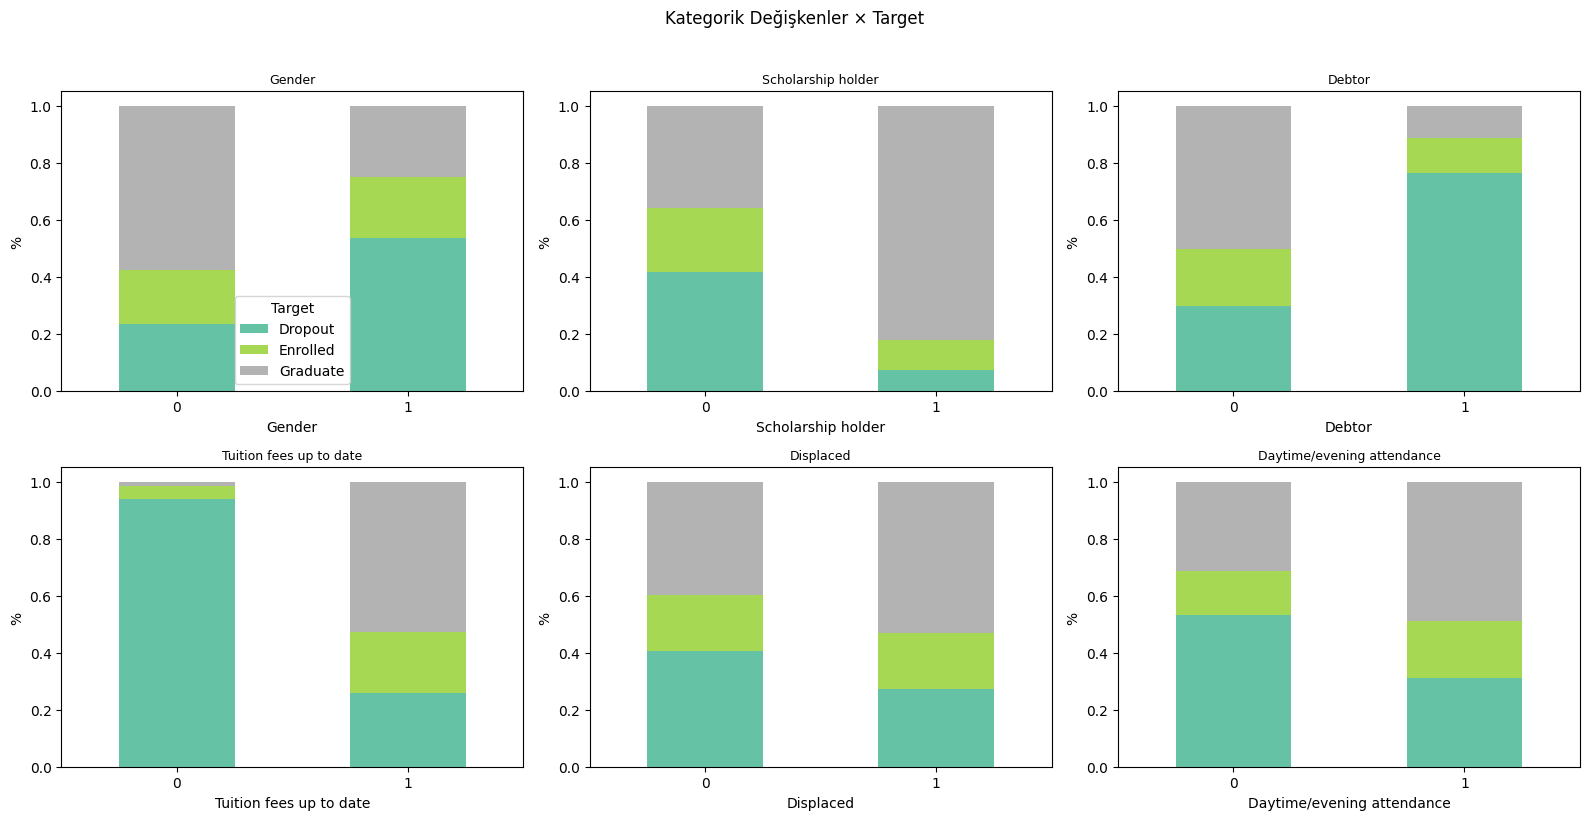

In [16]:
#Categorical Cols
cat_cols = ['Gender', 'Scholarship holder', 'Debtor',
            'Tuition fees up to date', 'Displaced', 'Daytime/evening attendance']

plt.figure(figsize=(16, 8))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(2, 3, i)
    pd.crosstab(train[col], train['Target'], normalize='index').plot(
        kind='bar', stacked=True, ax=plt.gca(),
        colormap='Set2', legend=(i == 1)
    )
    plt.title(col, fontsize=9)
    plt.xticks(rotation=0)
    plt.ylabel('%')
plt.suptitle('Kategorik Değişkenler × Target', y=1.02)
plt.tight_layout()
plt.show()

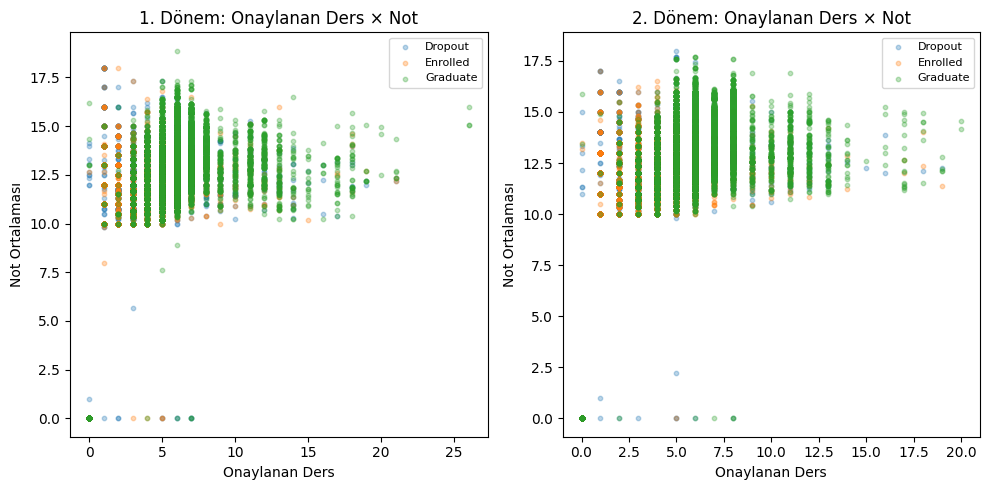

In [17]:
#1. ve 2. Dönem Başarı Karşılaştırması
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
for target, grp in train.groupby('Target'):
    plt.scatter(grp['Curricular units 1st sem (approved)'],
                grp['Curricular units 1st sem (grade)'],
                label=target, alpha=0.3, s=10)
plt.title('1. Dönem: Onaylanan Ders × Not')
plt.xlabel('Onaylanan Ders')
plt.ylabel('Not Ortalaması')
plt.legend(fontsize=8)

plt.subplot(1, 2, 2)
for target, grp in train.groupby('Target'):
    plt.scatter(grp['Curricular units 2nd sem (approved)'],
                grp['Curricular units 2nd sem (grade)'],
                label=target, alpha=0.3, s=10)
plt.title('2. Dönem: Onaylanan Ders × Not')
plt.xlabel('Onaylanan Ders')
plt.ylabel('Not Ortalaması')
plt.legend(fontsize=8)

plt.tight_layout()
plt.show()

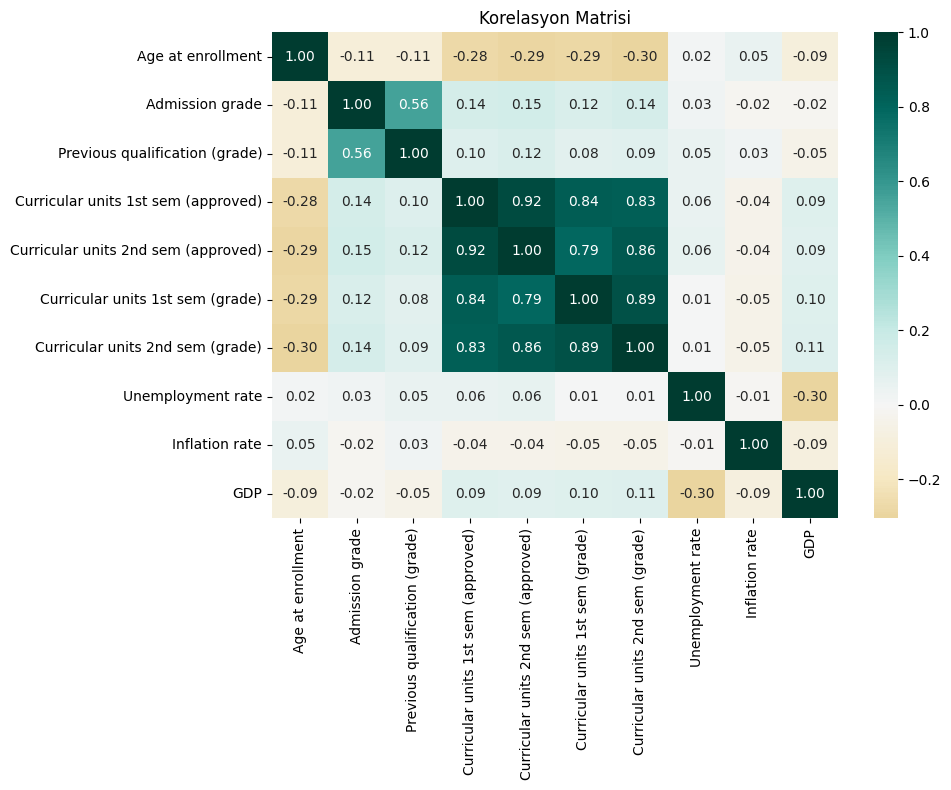

In [18]:
#Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(train[num_cols].corr(), annot=True, fmt='.2f', cmap='BrBG', center=0)
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()

## Feature Engineering

In [19]:
print(df['Curricular units 1st sem (enrolled)'].value_counts().sort_index().head())

Curricular units 1st sem (enrolled)
0    4355
1      66
2      64
3      79
4     293
Name: count, dtype: int64


In [20]:
#1. dönem başarı oranı 
df['1st_sem_success_rate'] = df['Curricular units 1st sem (approved)'] / \
                              df['Curricular units 1st sem (enrolled)'].replace(0, np.nan)
df['1st_sem_success_rate'].fillna(0, inplace=True)

In [21]:
df['2nd_sem_success_rate'] = (df['Curricular units 2nd sem (approved)'] / \
                               df['Curricular units 2nd sem (enrolled)'].replace(0, np.nan)).fillna(0)

In [22]:
# Toplam Onaylanan Ders & Not Ortalaması
df['total_approved'] = df['Curricular units 1st sem (approved)'] + \
                        df['Curricular units 2nd sem (approved)']


df['avg_grade'] = (df['Curricular units 1st sem (grade)'] + \
                    df['Curricular units 2nd sem (grade)']) / 2

In [23]:
df['grade_progress'] = df['Curricular units 2nd sem (grade)'] - \
                        df['Curricular units 1st sem (grade)']

In [24]:
df['Economic_Risk'] = df['Unemployment rate'] - df['GDP']
df['avg_admission_grade'] = (df['Admission grade'] + df['Previous qualification (grade)']) / 2

In [25]:
#Target encoding
target_map = {'Dropout': 0, 'Enrolled': 1, 'Graduate': 2}
df['Target'] = df['Target'].map(target_map)

In [26]:
abs(df.corr(numeric_only=True))['Target'].sort_values(ascending=False)

Target                                            1.000000
2nd_sem_success_rate                              0.806524
Curricular units 2nd sem (approved)               0.781452
total_approved                                    0.768917
1st_sem_success_rate                              0.755620
Curricular units 1st sem (approved)               0.725490
Curricular units 2nd sem (grade)                  0.719036
avg_grade                                         0.710870
Curricular units 1st sem (grade)                  0.661355
Tuition fees up to date                           0.415691
Scholarship holder                                0.394124
Gender                                            0.330181
Application mode                                  0.324830
Age at enrollment                                 0.320679
Curricular units 2nd sem (enrolled)               0.289165
Curricular units 1st sem (enrolled)               0.263657
Debtor                                            0.2483

In [27]:
drop_cols = [
    'Curricular units 1st sem (approved)', 'Curricular units 2nd sem (approved)',
    'Curricular units 1st sem (grade)', 'Curricular units 2nd sem (grade)',
    'Admission grade', 'Previous qualification (grade)',
    'id', 'Nacionality', 'International', 'Educational special needs',
    'Curricular units 1st sem (credited)', 'Curricular units 2nd sem (credited)',
    'Curricular units 1st sem (without evaluations)', 'Curricular units 2nd sem (without evaluations)',
    'Unemployment rate', 'Inflation rate', 'Economic_Risk',
    "Father's qualification", "Father's occupation",
    "Mother's occupation"
]

df.drop(columns=drop_cols, inplace=True)

In [28]:
df.shape

(127530, 25)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 127530 entries, 0 to 51011
Data columns (total 25 columns):
 #   Column                                  Non-Null Count   Dtype  
---  ------                                  --------------   -----  
 0   Marital status                          127530 non-null  int64  
 1   Application mode                        127530 non-null  int64  
 2   Application order                       127530 non-null  int64  
 3   Course                                  127530 non-null  int64  
 4   Daytime/evening attendance              127530 non-null  int64  
 5   Previous qualification                  127530 non-null  int64  
 6   Mother's qualification                  127530 non-null  int64  
 7   Displaced                               127530 non-null  int64  
 8   Debtor                                  127530 non-null  int64  
 9   Tuition fees up to date                 127530 non-null  int64  
 10  Gender                                  127530 non

## Train Test Split

In [31]:
train = df[df['Target'].notna()]
test  = df[df['Target'].isna()]

In [32]:
x = train.drop(columns=['Target'])
y = train['Target'].astype(int)

x_final_test = test.drop(columns=['Target'])

## Model Training

In [33]:
def algo_test(x, y):
    modeller = [
        BernoulliNB(),
        LogisticRegression(max_iter=500, solver='lbfgs'),
        DecisionTreeClassifier(),
        RandomForestClassifier(),
        GradientBoostingClassifier(),
        KNeighborsClassifier(),
        AdaBoostClassifier(),
        XGBClassifier(eval_metric='mlogloss', verbosity=0, random_state=42),
        LGBMClassifier(verbose=-1, random_state=42),
        CatBoostClassifier(verbose=0, random_state=42)
    ]
    isimler = [
        "BernoulliNB", "LogisticRegression", "DecisionTreeClassifier",
        "RandomForestClassifier", "GradientBoostingClassifier", "KNeighborsClassifier",
        "AdaBoostClassifier", "XGBClassifier", "LGBMClassifier", "CatBoostClassifier"
    ]

    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)

    accuracy, precision, recall, f1, mdl = [], [], [], [], []

    print("Modeller eğitiliyor...")
    for name, model in zip(isimler, modeller):
        print(f"  {name}...")
        try:
            model.fit(x_train, y_train)
            tahmin = model.predict(x_test)
            accuracy.append(accuracy_score(y_test, tahmin))
            precision.append(precision_score(y_test, tahmin, average="weighted"))
            recall.append(recall_score(y_test, tahmin, average="weighted"))
            f1.append(f1_score(y_test, tahmin, average="weighted"))
            mdl.append(model)
        except Exception as e:
            print(f"  HATA → {name}: {e}")
            accuracy.append(np.nan); precision.append(np.nan)
            recall.append(np.nan);   f1.append(np.nan); mdl.append(None)

    metrics = pd.DataFrame({
        "Accuracy": accuracy, "Precision": precision,
        "Recall": recall,     "F1": f1, "Model": mdl
    }, index=isimler).sort_values("F1", ascending=False)

    print("\n" + "="*80)
    print("En başarılı model:", metrics.dropna().iloc[0].name)
    print("="*80)

    en_iyi = metrics.dropna().iloc[0]["Model"]
    tahmin = en_iyi.predict(x_test)
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, tahmin))
    print("\nClassification Report:")
    print(classification_report(y_test, tahmin))
    print("\nTÜM MODELLER:")
    print(metrics.drop("Model", axis=1))

    return metrics.drop("Model", axis=1)

results = algo_test(x, y)

Modeller eğitiliyor...
  BernoulliNB...
  LogisticRegression...
  DecisionTreeClassifier...
  RandomForestClassifier...
  GradientBoostingClassifier...
  KNeighborsClassifier...
  AdaBoostClassifier...
  XGBClassifier...
  LGBMClassifier...
  CatBoostClassifier...

En başarılı model: CatBoostClassifier

Confusion Matrix:
[[4205  516  307]
 [ 382 1806  829]
 [ 118  443 6698]]

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.84      0.86      5028
           1       0.65      0.60      0.62      3017
           2       0.85      0.92      0.89      7259

    accuracy                           0.83     15304
   macro avg       0.80      0.79      0.79     15304
weighted avg       0.83      0.83      0.83     15304


TÜM MODELLER:
                            Accuracy  Precision    Recall        F1
CatBoostClassifier          0.830436   0.827931  0.830436  0.828024
LGBMClassifier              0.829587   0.828285  0.829587  0.82770

In [34]:
best_model= CatBoostClassifier(verbose=0, random_state=42)
best_model.fit(x,y)

CatBoostClassifier(random_state=42, verbose=0)

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=.20, random_state=42)

In [36]:
pred = best_model.predict(x_test)

<Axes: >

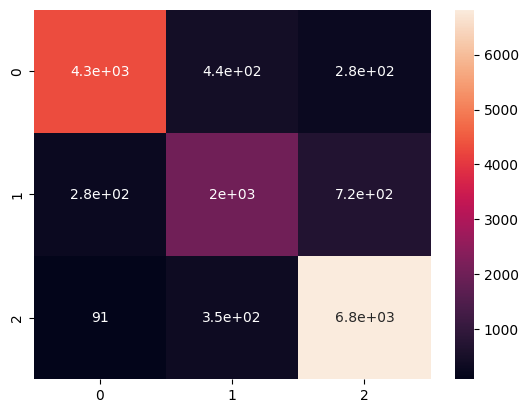

In [37]:
sns.heatmap(confusion_matrix(y_test,pred), annot=True)

In [38]:
pred_final= best_model.predict(x_final_test)

In [42]:
test_id= pd.read_csv('/kaggle/input/competitions/playground-series-s4e6/test.csv')['id'].values

In [44]:
submission = pd.DataFrame({
    'id': test_id,
    'Target': pred_final.ravel()
})


target_map = {0: 'Dropout', 1: 'Enrolled', 2: 'Graduate'}
submission['Target'] = submission['Target'].map(target_map)

In [45]:
submission.head()

,id,Target
0,76518,Dropout
1,76519,Graduate
2,76520,Graduate
3,76521,Graduate
4,76522,Dropout


In [46]:
submission.to_csv('submission.csv', index=False)